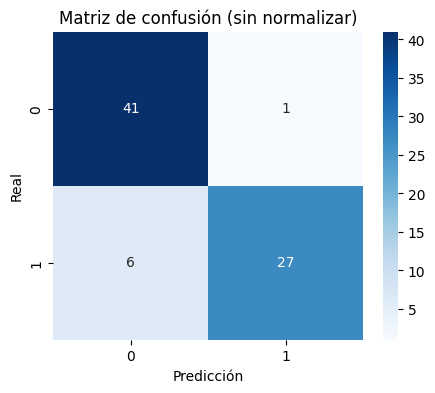

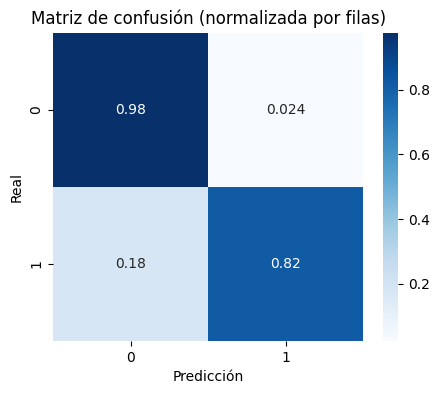

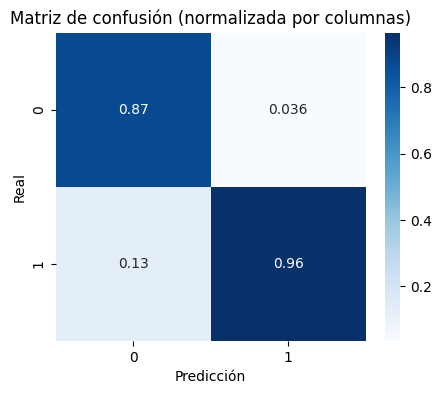

=== Classification Report (con categóricos) ===
              precision    recall  f1-score   support

           0       0.87      0.98      0.92        42
           1       0.96      0.82      0.89        33

    accuracy                           0.91        75
   macro avg       0.92      0.90      0.90        75
weighted avg       0.91      0.91      0.91        75



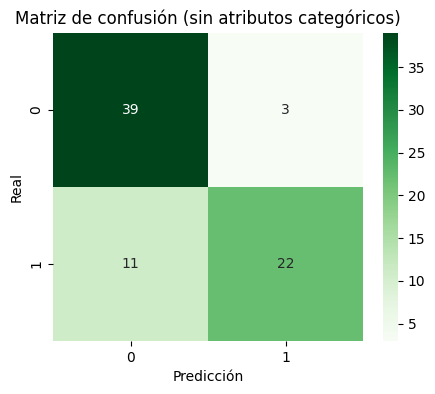

=== Classification Report (sin categóricos) ===
              precision    recall  f1-score   support

           0       0.78      0.93      0.85        42
           1       0.88      0.67      0.76        33

    accuracy                           0.81        75
   macro avg       0.83      0.80      0.80        75
weighted avg       0.82      0.81      0.81        75



In [1]:
# ACTIVIDAD 3.9 - CLASIFICACIÓN ENFERMEDADES CORAZÓN

# 1. IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# 2. CARGAR DATASET CLEVELAND

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columnas = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, names=columnas)

# Reemplazar '?' por NaN y convertir a numérico
df.replace("?", np.nan, inplace=True)
df = df.apply(pd.to_numeric)

# Eliminar filas con valores faltantes
df.dropna(inplace=True)

# 3. VARIABLE OBJETIVO BINARIA
# 0 = No enfermedad
# 1 = Enfermedad

df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

# 4. DEFINICIÓN DE ATRIBUTOS

# Dicotómicos (se usan como numéricos)
dicotomicos = ["sex", "fbs", "exang"]

# Categóricos (conjunto cerrado de valores)
categoricos = ["cp", "restecg", "slope", "ca", "thal"]

# CASO A: USANDO TODOS LOS ATRIBUTOS

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modelo = GaussianNB()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

# MATRIZ DE CONFUSIÓN (NORMAL)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión (sin normalizar)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# MATRIZ NORMALIZADA POR FILAS

cm_filas = confusion_matrix(y_test, y_pred, normalize="true")

plt.figure(figsize=(5,4))
sns.heatmap(cm_filas, annot=True, cmap="Blues")
plt.title("Matriz de confusión (normalizada por filas)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# MATRIZ NORMALIZADA POR COLUMNAS

cm_columnas = confusion_matrix(y_test, y_pred, normalize="pred")

plt.figure(figsize=(5,4))
sns.heatmap(cm_columnas, annot=True, cmap="Blues")
plt.title("Matriz de confusión (normalizada por columnas)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# CLASSIFICATION REPORT

print("=== Classification Report (con categóricos) ===")
print(classification_report(y_test, y_pred))

# CASO B: ELIMINANDO ATRIBUTOS CATEGÓRICOS

X_sin_cat = df.drop(columns=categoricos + ["target"])
y = df["target"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_sin_cat, y, test_size=0.25, random_state=42
)

modelo2 = GaussianNB()
modelo2.fit(X_train2, y_train2)

y_pred2 = modelo2.predict(X_test2)

# MATRIZ DE CONFUSIÓN (SIN CATEGÓRICOS)

cm2 = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión (sin atributos categóricos)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# CLASSIFICATION REPORT (SIN CATEGÓRICOS)

print("=== Classification Report (sin categóricos) ===")
print(classification_report(y_test2, y_pred2))
